# Introduction to Pandas


## What is Pandas

Pandas is a powerful open-source **data manipulation and analysis library** for Python. It provides easy-to-use data structures and functions for working with structured data, making it an essential tool for data scientists, analysts, and developers. Pandas is especially popular for its ability to **handle data in a tabular format**, similar to a spreadsheet, which includes rows and columns.

## Pandas Key Functionalities

### Read a File

Pandas provides a simple and efficient way to read data from `CSV` files. In this section, we will demonstrate how to read the dataset from a CSV file 

Let's begin by importing the Pandas library and then use the `read_csv` function to read the data from the CSV file and store it in a Pandas DataFrame. 


In [1]:
import pandas as pd

file_path = '../supervised_learning/data/coinbaseUSD_1-min_data_2014-12-01_to_2019-01-09.csv'
df = pd.read_csv(file_path)

### Explore the Basic Structure of the DataFrame

Let's start by exploring the basic structure and content of our DataFrame.

#### Data Overview

- The `info()` method provides a concise summary of the DataFrame, including the number of non-null values, data types, and memory usage. It's useful for understanding the data types and identifying missing values.

- `head()` and `tail()`: These methods allow you to view the first or last `N` rows of the DataFrame to get a quick overview of the data's structure.

- The `shape` attribute returns a tuple representing the dimensions of the DataFrame (number of rows, number of columns).

#### Data Summary Statistics

- The `describe()` method generates summary statistics for numeric columns, such as count, mean, standard deviation, minimum, and maximum values. This method is particularly helpful for understanding the distribution of your data.


- The `nunique()` method counts the number of unique values in each column. It's useful for understanding the cardinality of categorical columns.


- The `value_counts()` method is used with a specific column and returns the frequency of each unique value in that column. It's handy for categorical variables.


#### Column Information

- The `columns` attribute returns a list of column names in the DataFrame.

- The `dtypes` show the data types of each column.

#### Missing Data Handling

- `isna()` and `isnull()`: These methods help identify missing values in the DataFrame. They return a DataFrame of Boolean values where `True` indicates missing values.

In [10]:
df.isna()

,Timestamp,Open,High,Low,Close,Volume_(BTC),Volume_(Currency),Weighted_Price
0,False,False,False,False,False,False,False,False
1,False,True,True,True,True,True,True,True
2,False,True,True,True,True,True,True,True
3,False,True,True,True,True,True,True,True
4,False,True,True,True,True,True,True,True
...,...,...,...,...,...,...,...,...
2099755,False,False,False,False,False,False,False,False
2099756,False,False,False,False,False,False,False,False
2099757,False,False,False,False,False,False,False,False
2099758,False,False,False,False,False,False,False,False


### Data Filtering and Selection

- `loc[]` and `iloc[]`: These methods allow for **data selection based on labels or integer-location**, respectively. They are useful for slicing and filtering data.


- Boolean Indexing: Use boolean expressions to filter rows that meet specific conditions

In [11]:
# Select rows and columns by label
df.loc[100000:100005, ['Open', 'Close']]

,Open,Close
100000,262.59,262.52
100001,262.49,262.51
100002,262.40,262.32
100003,262.63,262.71
100004,262.52,262.52
100005,262.61,262.54


In [12]:
# Select rows and columns by position
df.iloc[100000:100005, 1:4]

,Open,High,Low
100000,262.59,262.59,262.46
100001,262.49,262.51,262.49
100002,262.40,262.56,262.20
100003,262.63,262.71,262.63
100004,262.52,262.52,262.52


In [24]:
# Filter rows where 'Close' price is greater than 100
filtered_data = df[df['Close'] > 100][['Timestamp', 'Close']]
filtered_data

,Timestamp,Close
0,1417411980,300.00
7,1417412400,300.00
51,1417415040,370.00
77,1417416600,370.00
1436,1417498140,377.00
...,...,...
2099755,1546898520,4006.01
2099756,1546898580,4006.01
2099757,1546898640,4006.01
2099758,1546898700,4005.50


### Grouping and Aggregation

- `groupby()`: Group data based on one or more columns and then perform aggregations on the groups.

Let's use our dataset to group by `Close` price and calculate the mean of `Volume_(BTC)` within each group. Here's how you can do it:

In [27]:
# Group by 'Close' and calculate the mean of 'Volume_(BTC)' within each group
close_mean = df.groupby('Close')['Volume_(BTC)'].mean()
close_mean

Close
0.06        0.778747
109.94      0.010000
110.00      0.020000
110.48      0.020000
110.50      0.030000
              ...   
19890.68    6.104369
19890.99    5.046474
19891.00    8.703115
19891.98    7.110770
19891.99    1.336512
Name: Volume_(BTC), Length: 445377, dtype: float64

### Data Transformation

- `apply()`: Apply a function to each element or column of the DataFrame. Useful for custom data transformations.

In [28]:
# Apply a custom function to the 'Value' column
df['Close'].apply(lambda x: x * 2)

0           600.00
1              NaN
2              NaN
3              NaN
4              NaN
            ...   
2099755    8012.02
2099756    8012.02
2099757    8012.02
2099758    8011.00
2099759    8011.98
Name: Close, Length: 2099760, dtype: float64

### Sorting

- `sort_values()`: Sort the DataFrame based on one or more columns in ascending or descending order.

In [29]:
# Sort by 'Timestamp' in ascending order
df.sort_values('Close')


,Timestamp,Open,High,Low,Close,Volume_(BTC),Volume_(Currency),Weighted_Price
1189735,1492297320,0.06,0.06,0.06,0.06,0.778747,0.046725,0.060
6993,1421224620,109.94,109.94,109.94,109.94,0.010000,1.099400,109.940
7414,1421249880,166.61,166.61,110.00,110.00,0.020000,2.766100,138.305
7329,1421244780,147.27,147.27,110.48,110.48,0.020000,2.577500,128.875
7372,1421247360,131.27,131.27,110.50,110.50,0.030000,3.633600,121.120
...,...,...,...,...,...,...,...,...
2081346,1545793980,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2081347,1545794040,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2081348,1545794100,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2081349,1545794160,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Data Visualization

- `matplotlib` Integration: Use Pandas in conjunction with the matplotlib library for data visualization. You can create various plots such as histograms, scatter plots, and bar charts to visualize your data.

#### Time Series Plot:

You can create a time series plot to visualize how the `Close` price changes over time (using `Timestamp` on the x-axis and `Close` on the y-axis). This can help you identify trends and patterns in the data.

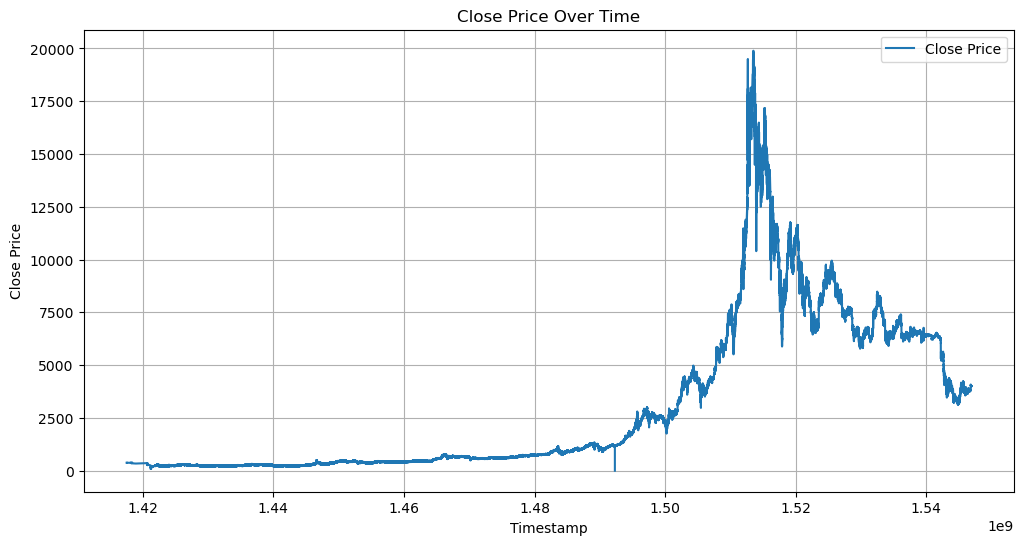

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(df['Timestamp'], df['Close'], label='Close Price')
plt.xlabel('Timestamp')
plt.ylabel('Close Price')
plt.title('Close Price Over Time')
plt.legend()
plt.grid(True)
plt.show()



### Histogram:

Create a histogram to visualize the distribution of the '`Volume_(BTC)`' column. This can help you understand the trading volume distribution.

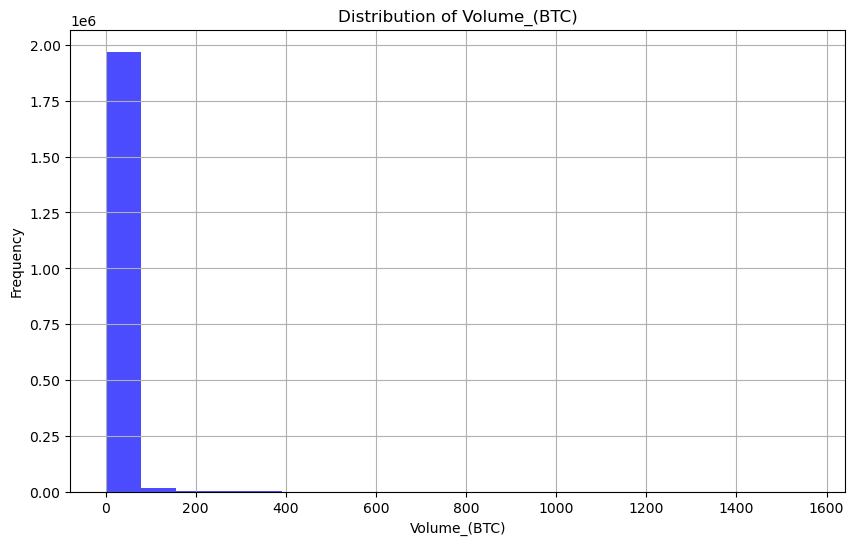

In [14]:
plt.figure(figsize=(10, 6))
plt.hist(df['Volume_(BTC)'], bins=20, color='blue', alpha=0.7)
plt.xlabel('Volume_(BTC)')
plt.ylabel('Frequency')
plt.title('Distribution of Volume_(BTC)')
plt.grid(True)
plt.show()


### Box Plot:

Create a box plot to visualize the distribution of '`Volume_(Currency)`' within different '`Close`' price ranges. This can help you identify potential outliers and understand the variability of trading volume.

Text(0.5, 1.0, 'Box Plot of Volume_(Currency) by Close Price Ranges')

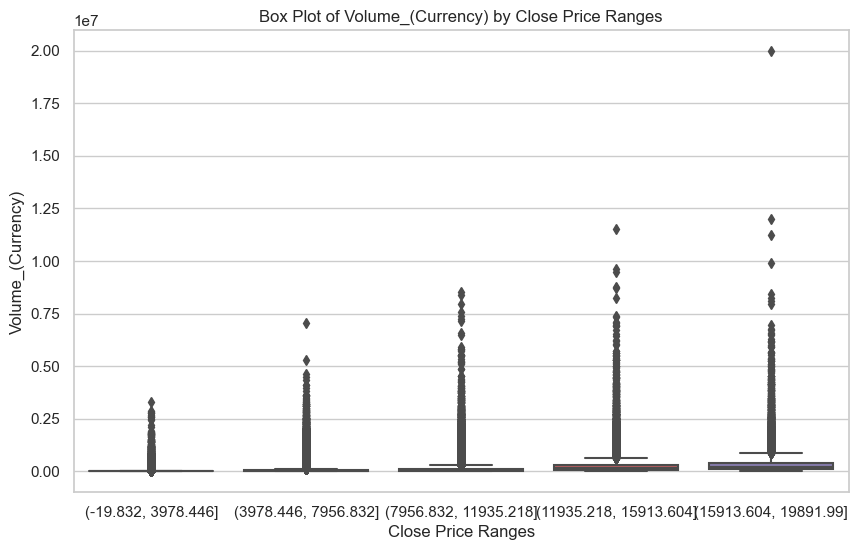

In [42]:
import seaborn as sns

sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.boxplot(x=pd.cut(df['Close'], bins=5), y='Volume_(Currency)', data=df)
plt.xlabel('Close Price Ranges')
plt.ylabel('Volume_(Currency)')
plt.title('Box Plot of Volume_(Currency) by Close Price Ranges')


### Visualizations using Pandas Built In Tools

Pandas itself provides some basic visualization capabilities using built-in functions. Here are a few simple visualizations you can create using Pandas:

#### Line Plot:
You can create a basic line plot to visualize the `Close` prices over time using the Pandas `plot()` method.

<Axes: title={'center': 'Close Price Over Time'}, xlabel='Timestamp', ylabel='Close Price'>

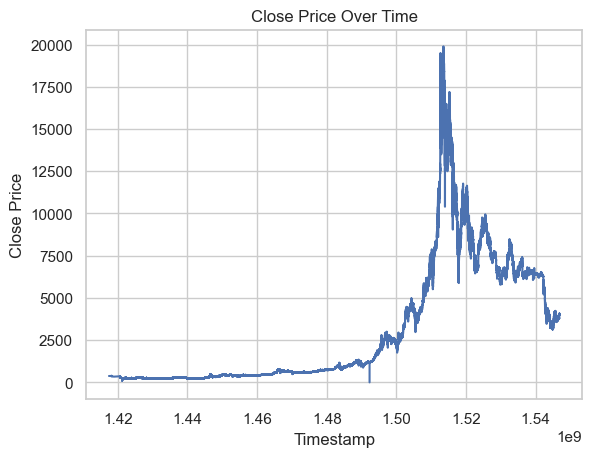

In [43]:
# Plot 'Close' prices over time
df.plot(x='Timestamp', y='Close', title='Close Price Over Time', xlabel='Timestamp', ylabel='Close Price', legend=False)